In [147]:
from skimage import io, color
from skimage.morphology import binary_closing, binary_opening
from skimage.morphology import disk
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure
from skimage.color import label2rgb
import pydicom as dicom
from scipy.stats import norm
from scipy.spatial import distance


def show_comparison(original, modified, modified_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True, sharey=True)
    ax1.imshow(original, cmap="gray", vmin=-200, vmax=500)
    ax1.set_title("Original")
    ax1.axis("off")
    ax2.imshow(modified)
    ax2.set_title(modified_name)
    ax2.axis("off")
    io.show()

## CT scan nonsense

In [148]:
in_dir = "data/"
ct = dicom.dcmread(in_dir + "Training.dcm")
img = ct.pixel_array
print(img.shape)
print(img.dtype)

(512, 512)
int16


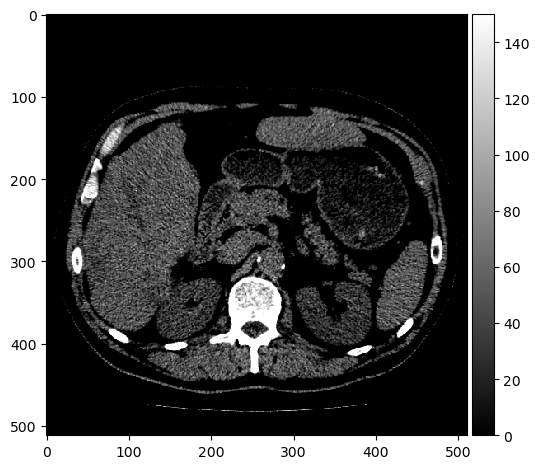

In [149]:
io.imshow(img, vmin=0, vmax=150, cmap='gray')
io.show()

An expert has provided annotations of bone, fat, kidneys, liver and spleen. They are stored as mask files which is an image with the same size as the input image, where the annotated pixels are 1 and the rest are 0. They are found as BoneROI.png, FatROI.png, KidneyROI.png, LiverROI and SpleenROI.png.

In [150]:
import glob
import re

In [151]:
masks = {}
for ROI_images in glob.glob("data/*ROI.png"):
    better_name = re.search("[^/]+(?=\.\w+$)", ROI_images).group()
    mask = io.imread(ROI_images) > 0
    masks[better_name] = mask
masks.keys()

dict_keys(['LiverROI', 'KidneyROI', 'SpleenROI', 'FatROI', 'BackgroundROI', 'BoneROI', 'TrabecROI'])

In [152]:
spleen_roi = io.imread(in_dir + "SpleenROI.png")
# convert to boolean image
spleen_mask = spleen_roi > 0
spleen_values = img[masks["SpleenROI"]]
spleen_values.shape, spleen_values

((2230,), array([55, 54, 36, ..., 65, 70, 66], dtype=int16))

In [153]:
mu_spleen = np.mean(spleen_values)
std_spleen = np.std(spleen_values)
mu_spleen, std_spleen

(49.48026905829597, 14.9970794143059)

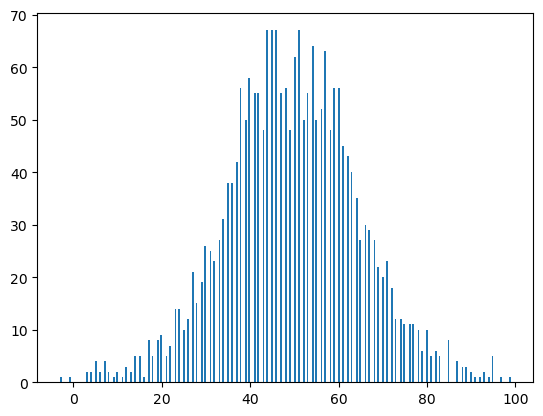

In [154]:
plt.hist(spleen_values, bins=256)
plt.show()

### fit gaussian distribution

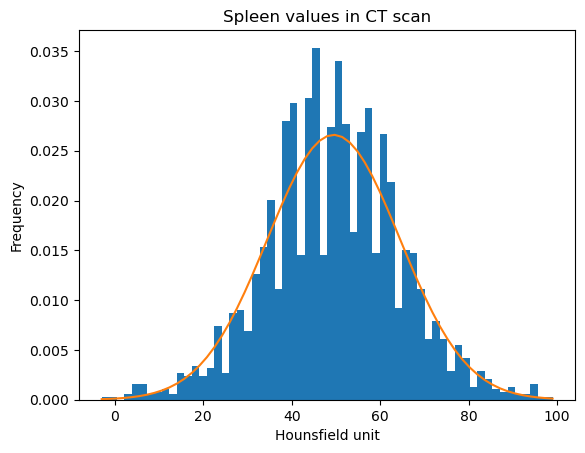

In [155]:
n, bins, patches = plt.hist(spleen_values, 60, density=1)
pdf_spleen = norm.pdf(bins, mu_spleen, std_spleen)
plt.plot(bins, pdf_spleen)
plt.xlabel("Hounsfield unit")
plt.ylabel("Frequency")
plt.title("Spleen values in CT scan")
plt.show()

### All classes

In [156]:
masks.keys()

dict_keys(['LiverROI', 'KidneyROI', 'SpleenROI', 'FatROI', 'BackgroundROI', 'BoneROI', 'TrabecROI'])

In [157]:
part_statistics = np.zeros((len(masks), 2))
idx = 0
for body_part, mask in masks.items():
    body_part_values = img[mask]
    mean = np.mean(body_part_values)
    sd = np.mean(body_part_values)
    part_statistics[idx] = np.array(mean, sd)
    idx += 1
part_statistics.shape, part_statistics
liver_statistics = part_statistics[0]
kidney_statistics = part_statistics[1]
spleen_statistics = part_statistics[2]
fat_statistics = part_statistics[3]
background_statistics = part_statistics[4]
bone_statistics = part_statistics[5]
trabec_statistics = part_statistics[6]

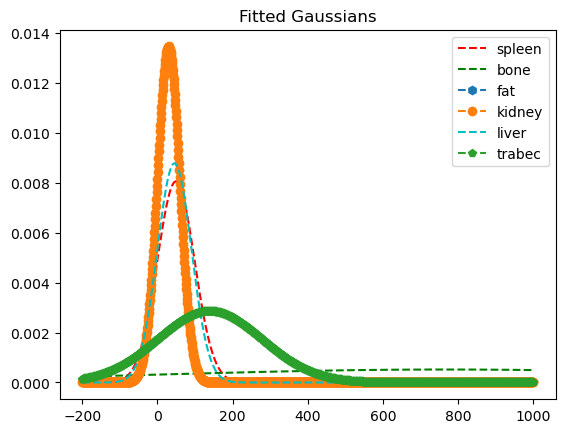

In [158]:
# Hounsfield unit limits of the plot
min_hu = -200
max_hu = 1000
hu_range = np.arange(min_hu, max_hu, 1.0)
pdf_spleen = norm.pdf(hu_range, spleen_statistics[0], spleen_statistics[1])
pdf_bone = norm.pdf(hu_range, bone_statistics[0], bone_statistics[1])
pdf_fat = norm.pdf(hu_range, fat_statistics[0], fat_statistics[1])
pdf_liver = norm.pdf(hu_range, liver_statistics[0], liver_statistics[1])
pdf_kidney = norm.pdf(hu_range, kidney_statistics[0], kidney_statistics[1])
pdf_trabec = norm.pdf(hu_range, trabec_statistics[0], trabec_statistics[1])
plt.plot(hu_range, pdf_spleen, "r--", label="spleen")
plt.plot(hu_range, pdf_bone, "g--", label="bone")
plt.plot(hu_range, pdf_fat, "h--", label="fat")
plt.plot(hu_range, pdf_kidney, "o--", label="kidney")
plt.plot(hu_range, pdf_liver, "c--", label="liver")
plt.plot(hu_range, pdf_trabec, "p--", label="trabec")
plt.title("Fitted Gaussians")
plt.legend()
plt.show()

## Minimum distance pixel classification
In the minimum distance classifier the pixel value class ranges are defined using the average values of the training values. If you have two classes, the threshold between them is defined as the mid-point between the two class value averages.

In the following, we will define four classes: background, fat, soft tissue and bone, where soft-tissue is a combination of the values of the spleen, liver and kidneys. We manually set the threshold for background to -200. So all pixels below -200 are set to background.



In [159]:
fat = fat_statistics[0]
soft = (spleen_statistics[0] + kidney_statistics[0] + liver_statistics[0]) / 3
sd_soft = (spleen_statistics[1] + kidney_statistics[1] + liver_statistics[1]) / 3


In [160]:
t_background = -200
t_fat_soft = (soft + fat) / 2
t_soft_bone = (soft + bone_statistics[0]) / 2
fat_img = (img > t_background) & (img <= t_fat_soft)
soft_tissue_img = (img > t_fat_soft) & (img <= t_soft_bone)
bone_img = img > t_soft_bone

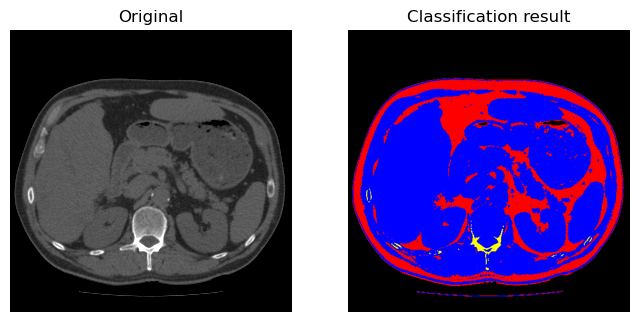

In [161]:
label_img = fat_img + 2 * soft_tissue_img + 3 * bone_img
image_label_overlay = label2rgb(label_img)
show_comparison(img, image_label_overlay, "Classification result")

## Parametric pixel classification
In the parametric classifier, the standard deviation of the training pixel values is also used when determinin the class ranges. In the following, we are also trying to classify background, fat, soft tissue and bone.

We start by finding the class ranges by manually inspecting the fitted Gaussians from each class.

As in the last exercise, we can still se the background-fat threshold to be -200.

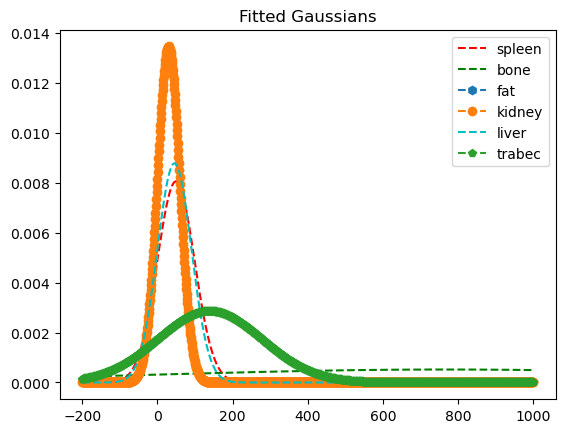

In [162]:
# Hounsfield unit limits of the plot
min_hu = -200
max_hu = 1000
hu_range = np.arange(min_hu, max_hu, 1.0)
pdf_spleen = norm.pdf(hu_range, spleen_statistics[0], spleen_statistics[1])
pdf_bone = norm.pdf(hu_range, bone_statistics[0], bone_statistics[1])
pdf_fat = norm.pdf(hu_range, fat_statistics[0], fat_statistics[1])
pdf_liver = norm.pdf(hu_range, liver_statistics[0], liver_statistics[1])
pdf_kidney = norm.pdf(hu_range, kidney_statistics[0], kidney_statistics[1])
pdf_trabec = norm.pdf(hu_range, trabec_statistics[0], trabec_statistics[1])
plt.plot(hu_range, pdf_spleen, "r--", label="spleen")
plt.plot(hu_range, pdf_bone, "g--", label="bone")
plt.plot(hu_range, pdf_fat, "h--", label="fat")
plt.plot(hu_range, pdf_kidney, "o--", label="kidney")
plt.plot(hu_range, pdf_liver, "c--", label="liver")
plt.plot(hu_range, pdf_trabec, "p--", label="trabec")
plt.title("Fitted Gaussians")
plt.legend()
plt.show()

### manual inspection

In [163]:
soft_mean = 50
bone_mean = 1000
# -ve for fat
fat_mean = -1000
t_background = -200
t_fat_soft = (soft_mean + fat_mean) / 2
t_soft_bone = (soft_mean + bone_mean) / 2
fat_img = (img > t_background) & (img <= t_fat_soft)
soft_tissue_img = (img > t_fat_soft) & (img <= t_soft_bone)
bone_img = img > t_soft_bone

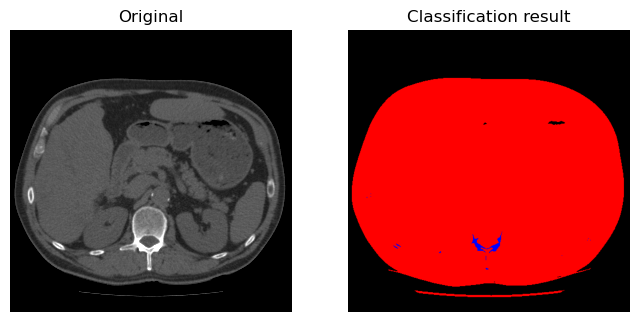

In [164]:
label_img = fat_img + 2 * soft_tissue_img + 3 * bone_img
image_label_overlay = label2rgb(label_img)
show_comparison(img, image_label_overlay, "Classification result")

### pdf

In [184]:
# Create a pixel lookup table
# range of hu units
max_range = 1200
start = -300
lookup_table = [""] * max_range
mu_soft = soft
std_soft = sd_soft
print(mu_soft)
mu_bone = bone_statistics[0]
std_bone = bone_statistics[1]
mu_fat = fat_statistics[0]
std_fat = fat_statistics[1]
for test_value in range(start, start + max_range):
    results =  [
        ("bone", norm.pdf(test_value, mu_bone, std_bone)),
        ("fat", norm.pdf(test_value, mu_fat, std_fat)),
        ("soft", norm.pdf(test_value, mu_soft, std_soft))
    ]
    sorted_results = max(results, key= lambda tup: tup[1])
    print(sorted_results)
    best_class, value = sorted_results
    lookup_table[test_value + 300] = best_class


41.50032911360427
('bone', 0.00019764946143897348)
('bone', 0.00019800813953849597)
('bone', 0.0001983671312891542)
('bone', 0.00019872643603783754)
('bone', 0.0001990860531286537)
('bone', 0.0001994459819029288)
('bone', 0.00019980622169920624)
('bone', 0.00020016677185324635)
('bone', 0.00020052763169802588)
('bone', 0.0002008888005637378)
('bone', 0.00020125027777779045)
('bone', 0.00020161206266480704)
('bone', 0.0002019741545466257)
('bone', 0.0002023365527422987)
('bone', 0.0002026992565680923)
('bone', 0.00020306226533748612)
('bone', 0.0002034255783611733)
('bone', 0.00020378919494705967)
('bone', 0.00020415311440026383)
('bone', 0.00020451733602311667)
('bone', 0.0002048818591151614)
('bone', 0.00020524668297315315)
('bone', 0.00020561180689105868)
('bone', 0.00020597723016005666)
('bone', 0.00020634295206853703)
('bone', 0.00020670897190210114)
('bone', 0.0002070752889435617)
('bone', 0.0002074419024729427)
('bone', 0.00020780881176747906)
('bone', 0.00020817601610161705)
('b

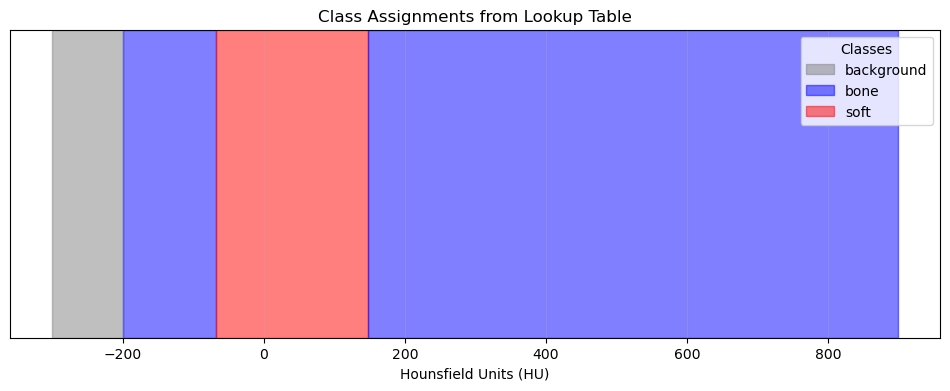

In [185]:
# Add background manually
background_threshold = -200
hu_values = np.arange(start, start + max_range)
for i, hu in enumerate(hu_values):
    if hu <= background_threshold:
        lookup_table[i] = "background"

# Visualize the LUT
plt.figure(figsize=(12, 4))
colors = {"background": "gray", "fat": "orange", "soft": "red", "bone": "blue"}
current_class = lookup_table[0]
start_idx = 0

# Plot each class region
for i in range(1, len(lookup_table)):
    if lookup_table[i] != current_class:
        plt.axvspan(
            hu_values[start_idx],
            hu_values[i],
            color=colors[current_class],
            alpha=0.5,
            label=(
                current_class
                if start_idx == 0
                or current_class not in plt.gca().get_legend_handles_labels()[1]
                else ""
            ),
        )
        start_idx = i
        current_class = lookup_table[i]

# Plot the last region
plt.axvspan(
    hu_values[start_idx],
    hu_values[-1],
    color=colors[current_class],
    alpha=0.5,
    label=(
        current_class
        if current_class not in plt.gca().get_legend_handles_labels()[1]
        else ""
    ),
)

# Customize the plot
plt.title("Class Assignments from Lookup Table")
plt.xlabel("Hounsfield Units (HU)")
plt.yticks([])  # Hide y-axis since it’s just regions
plt.legend(title="Classes")
plt.grid(True, alpha=0.3)
plt.show()

## The spleen finder nonsense

In [186]:
spleen_statistics[0], spleen_statistics[1]

(49.48026905829597, 49.48026905829597)

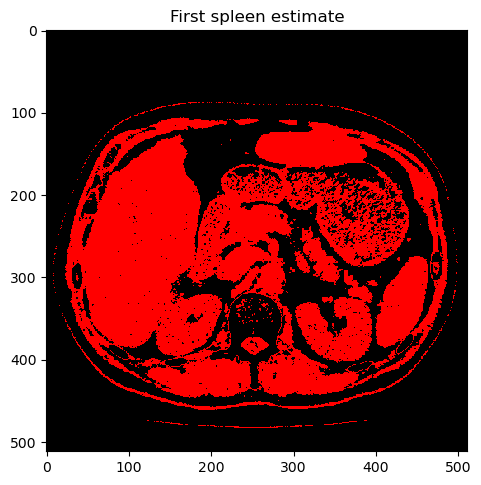

In [192]:
t_1, t_2 = 0, 100
spleen_estimate = (img > t_1) & (img < t_2)
spleen_label_colour = color.label2rgb(spleen_estimate)
io.imshow(spleen_label_colour)
plt.title("First spleen estimate")
io.show()

to show your first spleen estimate. As can be seen, there a many non-spleen areas in the result. The spleen is also connected to another anatomy.



### Morphological operations

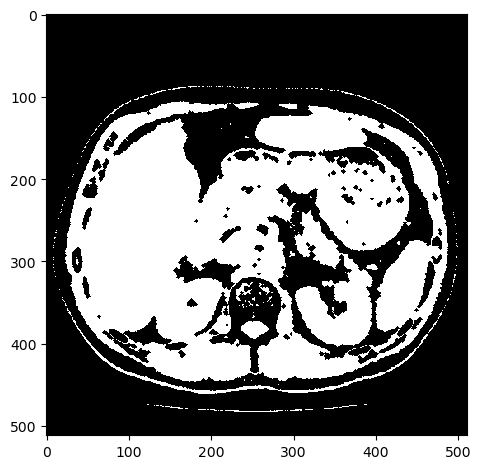

In [226]:
footprint = disk(2)
closed = binary_closing(spleen_estimate, footprint)

footprint = disk(10)
opened = binary_opening(closed, footprint)
io.imshow(closed)

### BLOB

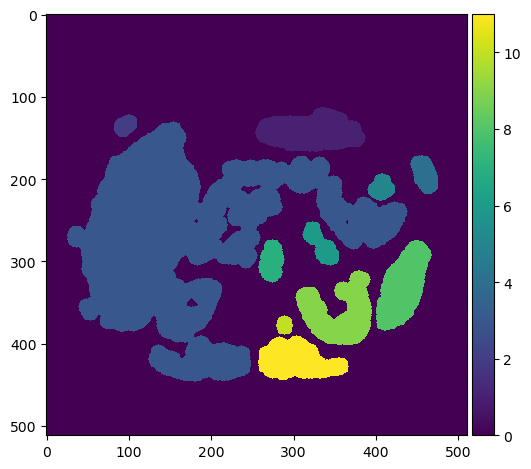

In [227]:
label_img = measure.label(opened)
io.imshow(label_img)

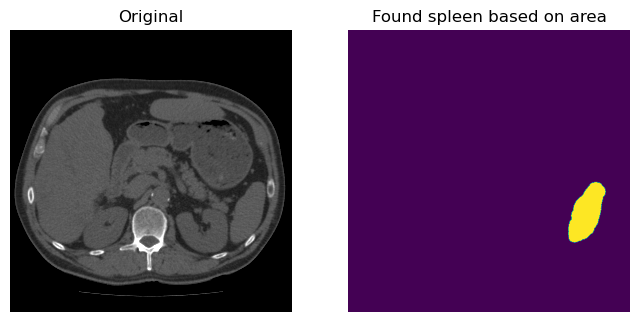

In [232]:
min_area = 4500
max_area = 5000
region_props = measure.regionprops(label_img)
# Create a copy of the label_img
label_img_filter = label_img.copy()
for region in region_props:
	# Find the areas that do not fit our criteria
	if region.area > max_area or region.area < min_area:
		# set the pixels in the invalid areas to background
		for cords in region.coords:
			label_img_filter[cords[0], cords[1]] = 0
# Create binary image from the filtered label image
i_area = label_img_filter > 0
show_comparison(img, i_area, 'Found spleen based on area')

## DICE score
![dice](data/DICE.png)

In [233]:
ground_truth_img = io.imread(in_dir + "Validation1_spleen.png")
gt_bin = ground_truth_img > 0
dice_score = 1 - distance.dice(i_area.ravel(), gt_bin.ravel())
print(f"DICE score {dice_score}")

DICE score 0.956305746866885
